# Big Mart Sales Prediction - 3

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


In [2]:
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

# ===== Phase 1: EDA and Data Cleaning =====

In [3]:
train = pd.read_csv("/content/train_v9rqX0R.csv")
test = pd.read_csv("/content/test_AbJTz2l.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (8523, 12)
Test shape: (5681, 11)


Handle Missing Item_Weight

In [4]:
item_weight_median = train.groupby("Item_Type")["Item_Weight"].median()

train["Item_Weight"] = train.apply(
    lambda x: item_weight_median[x["Item_Type"]]
    if pd.isnull(x["Item_Weight"]) else x["Item_Weight"],
    axis=1
)

test["Item_Weight"] = test.apply(
    lambda x: item_weight_median[x["Item_Type"]]
    if pd.isnull(x["Item_Weight"]) else x["Item_Weight"],
    axis=1
)


Handle Missing Outlet_Size

In [5]:
outlet_size_mode = (
    train.groupby("Outlet_Type")["Outlet_Size"]
    .agg(lambda x: x.mode()[0])
)

train["Outlet_Size"] = train.apply(
    lambda x: outlet_size_mode[x["Outlet_Type"]]
    if pd.isnull(x["Outlet_Size"]) else x["Outlet_Size"],
    axis=1
)

test["Outlet_Size"] = test.apply(
    lambda x: outlet_size_mode[x["Outlet_Type"]]
    if pd.isnull(x["Outlet_Size"]) else x["Outlet_Size"],
    axis=1
)


Fix Item_Visibility (replace zeros)

In [6]:
train.loc[train["Item_Visibility"] == 0, "Item_Visibility"] = np.nan
test.loc[test["Item_Visibility"] == 0, "Item_Visibility"] = np.nan

visibility_median = train.groupby("Item_Type")["Item_Visibility"].median()

train["Item_Visibility"] = train.apply(
    lambda x: visibility_median[x["Item_Type"]]
    if pd.isnull(x["Item_Visibility"]) else x["Item_Visibility"],
    axis=1
)

test["Item_Visibility"] = test.apply(
    lambda x: visibility_median[x["Item_Type"]]
    if pd.isnull(x["Item_Visibility"]) else x["Item_Visibility"],
    axis=1
)


Normalize Fat Content

In [7]:
mapping = {
    "lf": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular",
    "regular": "Regular"
}

for df in [train, test]:
    df["Item_Fat_Content"] = (
        df["Item_Fat_Content"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace(mapping)
    )


Verify

In [8]:
train["Item_Fat_Content"].value_counts()


,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


Create Outlet Age

In [9]:
CURRENT_YEAR = 2013

train["Outlet_Age"] = CURRENT_YEAR - train["Outlet_Establishment_Year"]
test["Outlet_Age"] = CURRENT_YEAR - test["Outlet_Establishment_Year"]


# ===== Phase 2: Feature Engineering =====

Visibility Ratio

In [10]:
visibility_mean = train.groupby("Item_Type")["Item_Visibility"].transform("mean")
train["Visibility_Ratio"] = train["Item_Visibility"] / visibility_mean

visibility_mean_map = train.groupby("Item_Type")["Item_Visibility"].mean()
test["Visibility_Ratio"] = (
    test["Item_Visibility"] /
    test["Item_Type"].map(visibility_mean_map)
)


Drop Collinear Feature

In [11]:
train.drop(columns=["Outlet_Establishment_Year"], inplace=True)
test.drop(columns=["Outlet_Establishment_Year"], inplace=True)


Binary Encode Fat Content

In [12]:
fat_encoding = {"Low Fat": 1, "Regular": 0}

train["Item_Fat_Content"] = train["Item_Fat_Content"].replace(fat_encoding).astype(int)
test["Item_Fat_Content"] = test["Item_Fat_Content"].replace(fat_encoding).astype(int)


Interaction Feature

In [13]:
train["Item_Outlet_Type"] = train["Item_Type"] + "_" + train["Outlet_Type"]
test["Item_Outlet_Type"] = test["Item_Type"] + "_" + test["Outlet_Type"]


Prepare Modeling Dataset

Separate Target

In [14]:
y = train["Item_Outlet_Sales"]
y_log = np.log1p(y)   # log transform target

X_raw = train.drop("Item_Outlet_Sales", axis=1)
test_raw = test.copy()


In [ ]:
# y = train["Item_Outlet_Sales"]
# X_raw = train.drop("Item_Outlet_Sales", axis=1)
# test_raw = test.copy()


Drop Identifiers

In [15]:
test_ids = test_raw[["Item_Identifier", "Outlet_Identifier"]]

X_raw.drop(columns=["Item_Identifier", "Outlet_Identifier"], inplace=True)
test_raw.drop(columns=["Item_Identifier", "Outlet_Identifier"], inplace=True)


One hot encoding

In [16]:
X_encoded = pd.get_dummies(X_raw, drop_first=True)
test_encoded = pd.get_dummies(test_raw, drop_first=True)

X_encoded, test_encoded = X_encoded.align(
    test_encoded,
    join="left",
    axis=1,
    fill_value=0
)


# ===== Phase 3: Model Training =====

Cross Validation

In [19]:

from sklearn.model_selection import GroupKFold, cross_val_score

gkf = GroupKFold(n_splits=5)
groups = train["Outlet_Identifier"]

gbr_v2 = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=145,
    min_samples_leaf=10,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

scores = cross_val_score(
    gbr_v2,
    X_encoded,
    y_log,
    scoring="neg_root_mean_squared_error",
    cv=gkf.split(X_encoded, y_log, groups),
    n_jobs=-1
)

print("Group CV RMSE (log scale):", -scores.mean())


Group CV RMSE (log scale): 0.9289675362172843


RMSE Training Curve

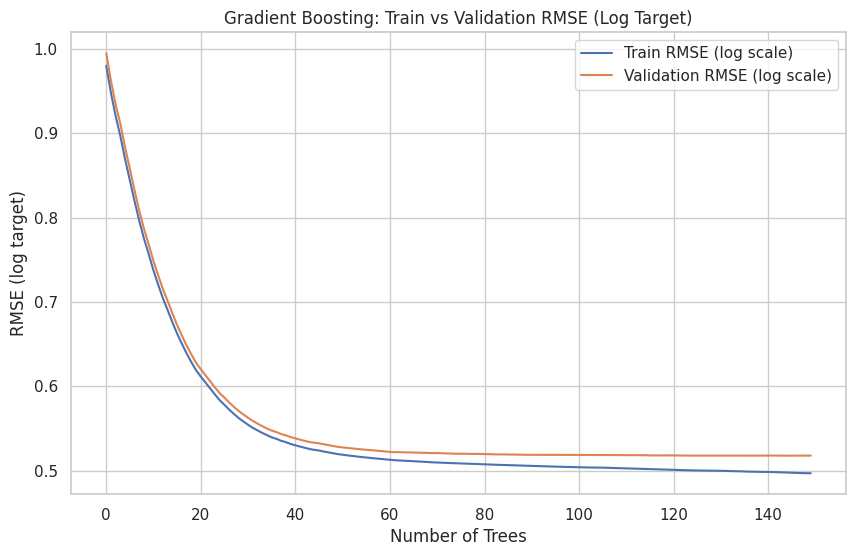

Best iteration (log scale): 145
Best Validation RMSE (log scale): 0.5175803310886644


In [18]:

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Create simple train-validation split for diagnostics
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded,
    y_log,
    test_size=0.2,
    random_state=42
)

# Initialize model (same as v2)
gbr_diag = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=150,  # Use slightly larger for visualization
    min_samples_leaf=10,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

gbr_diag.fit(X_train, y_train)

train_rmse = []
val_rmse = []

# Track performance at each boosting stage
for y_train_pred, y_val_pred in zip(
    gbr_diag.staged_predict(X_train),
    gbr_diag.staged_predict(X_val)
):
    train_rmse.append(
        np.sqrt(mean_squared_error(y_train, y_train_pred))
    )
    val_rmse.append(
        np.sqrt(mean_squared_error(y_val, y_val_pred))
    )

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_rmse, label="Train RMSE (log scale)")
plt.plot(val_rmse, label="Validation RMSE (log scale)")

plt.xlabel("Number of Trees")
plt.ylabel("RMSE (log target)")
plt.title("Gradient Boosting: Train vs Validation RMSE (Log Target)")
plt.legend()
plt.grid(True)
plt.show()

best_iter = np.argmin(val_rmse)
print("Best iteration (log scale):", best_iter + 1)
print("Best Validation RMSE (log scale):", val_rmse[best_iter])

Train model on data set

In [20]:
gbr_v2.fit(X_encoded, y_log)

GradientBoostingRegressor(learning_rate=0.05, max_depth=4, min_samples_leaf=10,
                          n_estimators=145, random_state=42, subsample=0.8)

Predict on Test Set

In [21]:
pred_log = gbr_v2.predict(test_encoded)
predictions = np.expm1(pred_log)

predictions = np.clip(predictions, 0, None)

print(predictions)

[1412.34830984 1242.2748756   497.37571081 ... 1654.0372144  3464.26870915
 1157.64422271]


In [22]:
submission_v2 = pd.DataFrame({
    "Item_Identifier": test_ids["Item_Identifier"],
    "Outlet_Identifier": test_ids["Outlet_Identifier"],
    "Item_Outlet_Sales": predictions
})

print("Submission rows:", submission_v2.shape[0])

submission_v2.to_csv("bigmart_submission_v2.csv", index=False)

submission_v2.head()



Submission rows: 5681


,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1412.348310
1,FDW14,OUT017,1242.274876
2,NCN55,OUT010,497.375711
3,FDQ58,OUT017,2316.249713
4,FDY38,OUT027,5322.228111


In [ ]:
submission = pd.read_csv('/content/bigmart_submission_v1.csv')

In [ ]:
print(submission.shape)

(5681, 3)
